In [2]:
import pandas as pd
import ast

Let's check on how different and how important the new mapping of the Job Titles to the SOC codes. After doing the new mapping, 584 / 1151 (51%) still have the same SOC codes with the old mapping

In [3]:
old_mca_df = pd.read_csv('../../01_mca_job_list/WorldBank/final_mca_aioe_comple.csv').sort_values(by='Job Title')
new_mca_df = pd.read_csv('../data/FINAL_mca_data.csv').sort_values(by='Job Title').rename(columns={'SOC Code': 'SOC'})
# recall that we need to convert a string to a list
new_mca_df['SOC Codes'] = new_mca_df['SOC Codes'].apply(ast.literal_eval)

In [4]:
# let's get the titles of the SOC
filename = '../data/labor_codes/ISCO_SOC_Crosswalk.xls'
isco_soc_df = pd.read_excel(filename,
                            usecols=[0, 3, 4],
                            names=['ISCO', 'SOC', 'SOC_Title'],
                            skiprows=6,
                            dtype={'ISCO': str, 'SOC': str, 'SOC_Title': str})
isco_soc_df['SOC'] = isco_soc_df['SOC'].str.strip()

# create the mappings for soc titles
old_mca_df['SOC'] = old_mca_df['SOC'].str.strip()
soc_title_map = dict(zip(isco_soc_df.SOC, isco_soc_df.SOC_Title))
old_mca_df['SOC Title'] = old_mca_df['SOC'].map(soc_title_map)

# combine the two
comparison_df = new_mca_df.merge(
    old_mca_df,
    on='Job Title',
    how='inner',
    suffixes=(' New', ' Old')
)

In [5]:
# I only want to flag a job when 
# 1) the new mapping differs from the old SOC AND 
# 2) there were multiple possible SOC codes to choose from.
is_different_SOC_code = comparison_df['SOC Old'] != comparison_df['SOC New'].str[:7]
is_multiple_SOC_codes = comparison_df['SOC Codes'].apply(set).apply(len) > 1
is_conflicting_old_new_soc_code = is_different_SOC_code & is_multiple_SOC_codes

In [6]:
comparison_df.loc[is_conflicting_old_new_soc_code, 'AIOE Percent Difference'].describe()

KeyError: 'AIOE Percent Difference'

In [ ]:
comparison_df.loc[is_different_SOC_code, ['Job Title', 'PSOC Code', 'SOC Titles', 'SOC Title Old', 'SOC Title New']].head(50)

,Job Title,PSOC Code,SOC Titles,SOC Title Old,SOC Title New
0,2D Echocardiography Technician,3211,"['Radiation Therapists', 'Diagnostic Medical S...",Magnetic Resonance Imaging Technologists,Radiologic Technologists and Technicians
1,2D Game Artist,2166,"['Special Effects Artists and Animators', 'Gra...",Graphic Designers,Special Effects Artists and Animators
2,3D Game Artist,2166,"['Special Effects Artists and Animators', 'Gra...",Graphic Designers,Special Effects Artists and Animators
3,3D Modeller,2166,"['Special Effects Artists and Animators', 'Gra...",Graphic Designers,Special Effects Artists and Animators
5,4-Wheel Tractor Mechanic,7233,"['First-Line Supervisors of Mechanics, Install...",Wind Turbine Service Technicians,Farm Equipment Mechanics and Service Technicians
6,AI Engineer,2512,['Software Quality Assurance Analysts and Test...,"Software Developers, Systems Software",Software Quality Assurance Analysts and Testers
7,AI Prompter,2529,"['Information Security Analysts', 'Computer Oc...",NaN,Information Security Analysts
10,Abaca Grower,6116,"['First-Line Supervisors of Farming, Fishing, ...","Farmworkers and Laborers, Crop, Nursery, and G...",Agricultural Equipment Operators
11,Academic Researcher,2131,"['Animal Scientists', 'Food Scientists and Tec...","Life Scientists, All Other","Biological Scientists, All Other"
13,Accounting Professional (Manufacturing),2411,"['Accountants and Auditors', 'Budget Analysts'...",Tax Preparers,Accountants and Auditors


In [ ]:
ambiguios_mapping_df = comparison_df.loc[is_conflicting_old_new_soc_code, ['Job Title', 'SOC Old', 'SOC Codes', 'SOC New']]

In [ ]:
(1151 - ambiguios_mapping_df.shape[0])/1151

0.5073848827106864

In [ ]:
1151 - ambiguios_mapping_df.shape[0]

584

In [ ]:
comparison_df['AIOE Difference'] = (
    comparison_df['AIOE New'] - comparison_df['AIOE Old']
)

comparison_df['AIOE Percent Difference'] = comparison_df['AIOE Difference'] / comparison_df['AIOE Old']

comparison_df['Complementarity Difference'] = (
    comparison_df['Complementarity New'] - comparison_df['Complementarity Old']
)

comparison_df['Complementarity Percent Difference'] = comparison_df['Complementarity Difference'] / comparison_df['Complementarity Old']

In [ ]:
comparison_df.loc[is_conflicting_old_new_soc_code, 'AIOE Percent Difference'].mean()

np.float64(-0.4083609534909956)

In [ ]:
comparison_df.loc[is_conflicting_old_new_soc_code, ['AIOE Old', 'AIOE New']].describe()

,AIOE Old,AIOE New
count,567.000000,567.000000
mean,-0.048358,0.075747
std,0.966222,0.913510
min,-2.202374,-2.790221
25%,-0.897994,-0.737070
50%,-0.124128,-0.056492
75%,0.724320,0.966410
max,1.452190,1.396908


array([[<Axes: title={'center': 'AIOE Old'}>,
        <Axes: title={'center': 'AIOE New'}>]], dtype=object)

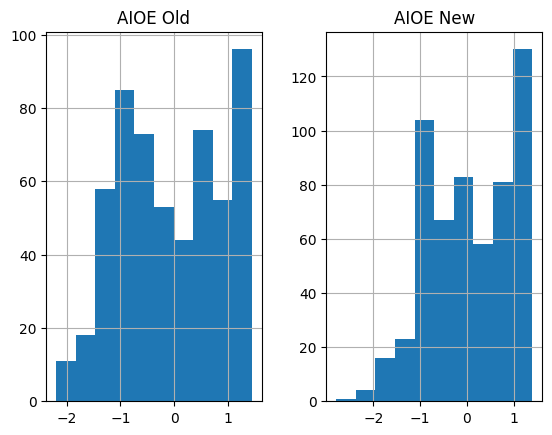

In [ ]:
comparison_df.loc[is_conflicting_old_new_soc_code, ['AIOE Old', 'AIOE New']].hist()

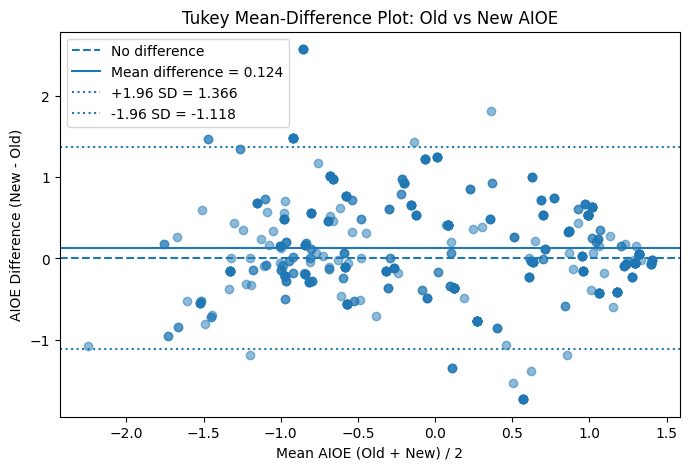

In [ ]:
import matplotlib.pyplot as plt

df = comparison_df[is_conflicting_old_new_soc_code].copy()
# Difference between new and old
df['AIOE Difference'] = df['AIOE New'] - df['AIOE Old']

# Average of old and new
df['AIOE Mean'] = (df['AIOE Old'] + df['AIOE New']) / 2

# Mean difference
mean_diff = df['AIOE Difference'].mean()

# Standard deviation of differences
sd_diff = df['AIOE Difference'].std()

# Limits of agreement
upper = mean_diff + 1.96 * sd_diff
lower = mean_diff - 1.96 * sd_diff

plt.figure(figsize=(8, 5))

plt.scatter(
    df['AIOE Mean'],
    df['AIOE Difference'],
    alpha=0.5
)

plt.axhline(0, linestyle='--', label='No difference')
plt.axhline(mean_diff, label=f'Mean difference = {mean_diff:.3f}')
plt.axhline(upper, linestyle=':', label=f'+1.96 SD = {upper:.3f}')
plt.axhline(lower, linestyle=':', label=f'-1.96 SD = {lower:.3f}')

plt.xlabel('Mean AIOE (Old + New) / 2')
plt.ylabel('AIOE Difference (New - Old)')
plt.title('Tukey Mean-Difference Plot: Old vs New AIOE')
plt.legend()
plt.show()

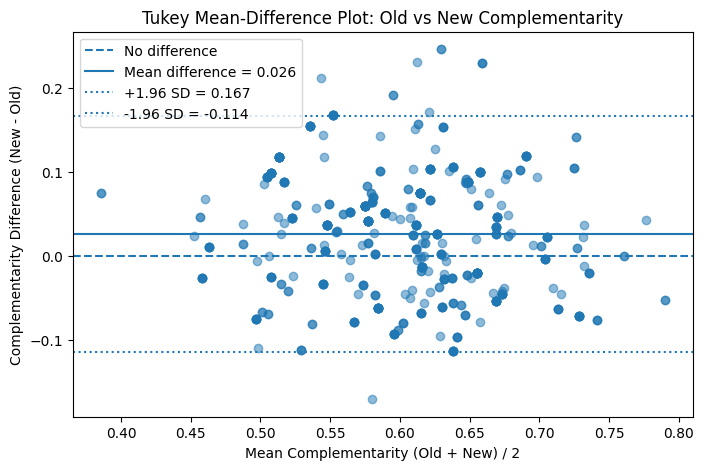

In [ ]:
import matplotlib.pyplot as plt

df = comparison_df[is_conflicting_old_new_soc_code].copy()

# Difference between new and old
df['Complementarity Difference'] = (
    df['Complementarity New'] - df['Complementarity Old']
)

# Average of old and new
df['Complementarity Mean'] = (
    df['Complementarity Old'] + df['Complementarity New']
) / 2

# Mean difference
mean_diff = df['Complementarity Difference'].mean()

# Standard deviation of differences
sd_diff = df['Complementarity Difference'].std()

# Limits of agreement
upper = mean_diff + 1.96 * sd_diff
lower = mean_diff - 1.96 * sd_diff

plt.figure(figsize=(8, 5))

plt.scatter(
    df['Complementarity Mean'],
    df['Complementarity Difference'],
    alpha=0.5
)

plt.axhline(
    0,
    linestyle='--',
    label='No difference'
)

plt.axhline(
    mean_diff,
    label=f'Mean difference = {mean_diff:.3f}'
)

plt.axhline(
    upper,
    linestyle=':',
    label=f'+1.96 SD = {upper:.3f}'
)

plt.axhline(
    lower,
    linestyle=':',
    label=f'-1.96 SD = {lower:.3f}'
)

plt.xlabel('Mean Complementarity (Old + New) / 2')
plt.ylabel('Complementarity Difference (New - Old)')
plt.title('Tukey Mean-Difference Plot: Old vs New Complementarity')
plt.legend()
plt.show()

In [ ]:
teacher_soc_codes = [
    '25-1126.00',
    '25-1071.00',
    '25-1042.00',
    '25-1022.00',
    '25-1199.00'
]

filtered_df = comparison_df[
    comparison_df['SOC New'].isin(teacher_soc_codes)
]
#filtered_df[['AIOE Old', 'AIOE New']]

In [ ]:
filtered_df

,Unnamed: 0 New,Job Title,Educational Qualification,Job Sector New,Educational Pathway New,HEI with PRC Exam,Some HEI New,Job Subsector New,PSOC Code,ISCO Code,...,SOC Old,AIOE Old,Complementarity Old,Classification,C-AIOE,SOC Title Old,AIOE Difference,AIOE Percent Difference,Complementarity Difference,Complementarity Percent Difference
42,506,Anatomy and Physiology Instructor,NaN,Education,Higher Education,No,No,Higher education,2310,2310,...,25-1199,0.72432,0.695328,Augmented,0.472984,"Postsecondary Teachers, All Other",0.534299,0.737656,-0.053106,-0.076376
103,514,Biology Instructor,NaN,Education,Higher Education,No,No,Higher education,2310,2310,...,25-1199,0.72432,0.695328,Augmented,0.472984,"Postsecondary Teachers, All Other",0.534299,0.737656,-0.053106,-0.076376
710,645,Mathematics Instructor,NaN,Education,Higher Education,No,No,Higher education,2310,2310,...,25-1199,0.72432,0.695328,Augmented,0.472984,"Postsecondary Teachers, All Other",0.534299,0.737656,-0.053106,-0.076376
823,673,Philosophy and Ethics Instructor,NaN,Education,Higher Education,No,No,Higher education,2310,2310,...,25-1199,0.72432,0.695328,Augmented,0.472984,"Postsecondary Teachers, All Other",0.534299,0.737656,-0.053106,-0.076376
924,197,Religious Research Assistant,Bachelor of Sacred Theology,"Professional, Scientific and Technical Activities",Higher Education,No,Yes,Research and experimental development on socia...,2310,2310,...,25-1199,0.72432,0.695328,Augmented,0.472984,"Postsecondary Teachers, All Other",0.534299,0.737656,-0.053106,-0.076376


In [9]:
comparison_df[comparison_df['Job Title'] == 'Police Officer'][['AIOE Old', 'AIOE New']]

,AIOE Old,AIOE New
840,-0.927186,-0.3051


In [10]:
comparison_df[comparison_df['Job Title'] == 'Police Officer'][['SOC Old', 'AIOE Old', 'SOC New', 'AIOE New']]

,SOC Old,AIOE Old,SOC New,AIOE New
840,33-3052,-0.927186,33-3051.00,-0.3051
